# 🎵 Spotify Top-10,000 Music Dataset: Complete Tour & Quickstart
Welcome to the comprehensive walkthrough of the **Spotify Top-10,000 Music Feature Dataset**!

This dataset provides **multi-modal embeddings, acoustic descriptors, emotion scores, and pre-computed similarity graphs** across 10,000 popular Spotify tracks.

---

### 📌 Universal Alignment Rule:
Every file in this dataset shares the exact same row alignment: **Row `i` in any `.parquet` or `.npy` file corresponds to Track `i` in `metadata/songs.parquet` / `track_ids.npy`**.


## 1. Environment Setup & Master Metadata (`metadata/`)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

# Robust path resolution for Local Repo or Kaggle environment
if Path('data/metadata/songs.parquet').exists():
    DATA_DIR = Path('data')
elif Path('../data/metadata/songs.parquet').exists():
    DATA_DIR = Path('../data')
elif Path('/kaggle/input/spotify-10k-music-features').exists():
    DATA_DIR = Path('/kaggle/input/spotify-10k-music-features')
else:
    raise FileNotFoundError("Could not locate dataset directory.")

print(f"Using dataset path: {DATA_DIR.resolve()}")

# Load master track metadata
songs = pd.read_parquet(DATA_DIR / 'metadata' / 'songs.parquet')
artists = pd.read_parquet(DATA_DIR / 'metadata' / 'artists.parquet')
genres = pd.read_parquet(DATA_DIR / 'metadata' / 'genres.parquet')
track_ids = np.load(DATA_DIR / 'track_ids.npy', allow_pickle=True)

print(f"Total songs: {len(songs):,}")
print(f"Total unique artists: {len(artists):,}")
print(f"Total genre tags: {len(genres):,}")

# Preview top popular tracks
songs[['track_name', 'artist_names', 'popularity', 'release_date', 'main_genres']].head()


Using dataset path: /home/esstee/projects/top10k/music-prediction/data
Total songs: 10,000
Total unique artists: 5,015
Total genre tags: 1,276


,track_name,artist_names,popularity,release_date,main_genres
0,Die With A Smile,Lady Gaga|Bruno Mars,100,2024-08-16,"Electronic, Pop"
1,DtMF,Bad Bunny,98,2025-01-05,"Hip Hop, Latin"
2,BIRDS OF A FEATHER,Billie Eilish,98,2024-05-17,Pop
3,Clean Baby Sleep White Noise (Loopable),Dream Supplier|Baby Sleeps|Background White Noise,97,2020-04-29,"Easy Listening, Electronic, New Age, Tradition..."
4,BAILE INoLVIDABLE,Bad Bunny,96,2025-01-05,"Hip Hop, Latin"


## 2. Classical Audio Features & Vocal Detection (`features/audio/`)
- `dsp_librosa.parquet`: 88 classical MIR descriptors (timbre, rhythm, harmony, loudness, stereo).
- `vad.parquet`: Silero Vocal Activity Detection (vocal ratio & duration).


In [2]:
# Load Audio DSP & VAD features
dsp = pd.read_parquet(DATA_DIR / 'features' / 'audio' / 'dsp_librosa.parquet')
vad = pd.read_parquet(DATA_DIR / 'features' / 'audio' / 'vad.parquet')

print(f"DSP feature table shape: {dsp.shape}")
print(f"VAD feature table shape: {vad.shape}")

# Inspect sample loudness (LUFS) and vocal ratio
audio_summary = pd.DataFrame({
    'track_name': songs['track_name'],
    'artist': songs['artist_names'],
    'tempo_bpm': dsp['tempo_librosa'],
    'loudness_lufs': dsp['lufs_integrated'],
    'vocal_ratio': vad['vocal_ratio'],
    'has_vocals': vad['has_vocals']
})
audio_summary.head()


DSP feature table shape: (10000, 91)
VAD feature table shape: (10000, 5)


,track_name,artist,tempo_bpm,loudness_lufs,vocal_ratio,has_vocals
0,Die With A Smile,Lady Gaga|Bruno Mars,161.499023,-11.008704,0.0623,True
1,DtMF,Bad Bunny,112.347145,-8.822250,0.4209,True
2,BIRDS OF A FEATHER,Billie Eilish,103.359375,-9.623411,0.0000,False
3,Clean Baby Sleep White Noise (Loopable),Dream Supplier|Baby Sleeps|Background White Noise,123.046875,-13.498037,0.0000,False
4,BAILE INoLVIDABLE,Bad Bunny,89.102913,-10.134287,0.0623,True


## 3. Deep Audio Embeddings & AudioSet Tag Probabilities (`embeddings/audio/`)
- `clap_512d.npy`: LAION-CLAP zero-shot text-audio embeddings (512-D).
- `mert_embeddings_768d.npy`: MERT-v1-95M self-supervised music transformer representations (768-D).
- `panns_tags_527d.npy`: Probabilities across 527 AudioSet classes.


In [3]:
# Load audio embeddings & PANNs tag probabilities
clap = np.load(DATA_DIR / 'embeddings' / 'audio' / 'clap_512d.npy')
mert = np.load(DATA_DIR / 'embeddings' / 'audio' / 'mert_embeddings_768d.npy')
panns_tags = np.load(DATA_DIR / 'embeddings' / 'audio' / 'panns_tags_527d.npy')

with open(DATA_DIR / 'embeddings' / 'audio' / 'panns_tags_labels.json') as f:
    audioset_labels = json.load(f)

print(f"CLAP shape: {clap.shape} (dtype: {clap.dtype})")
print(f"MERT shape: {mert.shape} (dtype: {mert.dtype})")
print(f"PANNs tags shape: {panns_tags.shape}")

# Look at top predicted sound/instrument classes for Track 0
track_idx = 0
# print track name and artist
top_tag_indices = np.argsort(panns_tags[track_idx])[-5:][::-1]
print(f"\nTrack: '{songs.iloc[track_idx]['track_name']}' by {songs.iloc[track_idx]['artist_names']}")
print(f"Top AudioSet Tags for '{songs.iloc[track_idx]['track_name']}':")
for idx in top_tag_indices:
    print(f"  - {audioset_labels[idx]}: {panns_tags[track_idx, idx]:.3f}")


CLAP shape: (10000, 512) (dtype: float32)
MERT shape: (10000, 768) (dtype: float32)
PANNs tags shape: (10000, 527)

Track: 'Die With A Smile' by Lady Gaga|Bruno Mars
Top AudioSet Tags for 'Die With A Smile':
  - Music: 0.734
  - Singing: 0.162
  - Pop music: 0.131
  - Music of Asia: 0.063
  - Speech: 0.052


## 4. Multilingual Lyric Embeddings & NLP Descriptors (`features/lyric/`, `embeddings/lyric/`)
- `multilingual_e5_large_1024d.npy` & `bge_m3_1024d.npy`: High-precision multilingual lyric representations.
- `language_id.parquet`: 35 language & script detection flags.
- `go_emotions.parquet`: 28 fine-grained emotion probability scores.
- `bertopic_topics.parquet`: 32 thematic lyric clusters.


In [4]:
# Load lyric embeddings & NLP features
e5_lyrics = np.load(DATA_DIR / 'embeddings' / 'lyric' / 'multilingual_e5_large_1024d.npy')
bge_lyrics = np.load(DATA_DIR / 'embeddings' / 'lyric' / 'bge_m3_1024d.npy')
lang_id = pd.read_parquet(DATA_DIR / 'features' / 'lyric' / 'language_id.parquet')
emotions = pd.read_parquet(DATA_DIR / 'features' / 'lyric' / 'go_emotions.parquet')
topics = pd.read_parquet(DATA_DIR / 'features' / 'lyric' / 'bertopic_topics.parquet')

with open(DATA_DIR / 'features' / 'lyric' / 'bertopic_topic_labels.json') as f:
    topic_labels = json.load(f)

print("Language distribution top 10:")
print(lang_id['primary_language'].value_counts().head(10))

# Show top emotions for a track
top_emotion_cols = emotions.columns[3:]
sample_emotions = emotions.iloc[0][top_emotion_cols].astype(float)
print(f"\nTop emotions for '{songs.iloc[0]['track_name']}':")
print(sample_emotions.sort_values(ascending=False).head(3))


Language distribution top 10:
primary_language
en      6218
es      1939
pt       435
none     203
id       185
hi       171
ko       162
tl        96
tr        93
ja        83
Name: count, dtype: int64

Top emotions for 'Die With A Smile':
emotion_love              0.6362
emotion_realization       0.2905
emotion_disappointment    0.1501
Name: 0, dtype: float64


## 5. Instant Similarity Search with Pre-computed kNN Graphs (`similarity/`)
- `knn_audio_top100.parquet`: Pre-computed Top-100 acoustic neighbors.
- `knn_lyric_top100.parquet`: Pre-computed Top-100 lyrical neighbors.


In [5]:
# Load similarity graphs
knn_audio = pd.read_parquet(DATA_DIR / 'similarity' / 'knn_audio_top100.parquet')
knn_lyric = pd.read_parquet(DATA_DIR / 'similarity' / 'knn_lyric_top100.parquet')

# Query a track (e.g. Track 10)
query_idx = 10
query_title = songs.iloc[query_idx]['track_name']
query_artist = songs.iloc[query_idx]['artist_names']

print(f"Target Song: '{query_title}' by {query_artist}")

print("\n🎵 Top 3 Acoustically Most Similar Songs:")
for neighbor_idx, sim in zip(knn_audio.iloc[query_idx]['top100_neighbor_indices'][:3], knn_audio.iloc[query_idx]['top100_similarities'][:3]):
    print(f"  - '{songs.iloc[neighbor_idx]['track_name']}' by {songs.iloc[neighbor_idx]['artist_names']} (Similarity: {sim:.3f})")

print("\n📝 Top 3 Lyrically Most Similar Songs:")
for neighbor_idx, sim in zip(knn_lyric.iloc[query_idx]['top100_neighbor_indices'][:3], knn_lyric.iloc[query_idx]['top100_similarities'][:3]):
    print(f"  - '{songs.iloc[neighbor_idx]['track_name']}' by {songs.iloc[neighbor_idx]['artist_names']} (Similarity: {sim:.3f})")


Target Song: 'WILDFLOWER' by Billie Eilish

🎵 Top 3 Acoustically Most Similar Songs:
  - 'TV' by Billie Eilish (Similarity: 0.964)
  - 'THE GREATEST' by Billie Eilish (Similarity: 0.963)
  - 'Little Bit Better' by Caleb Hearn|ROSIE (Similarity: 0.957)

📝 Top 3 Lyrically Most Similar Songs:
  - 'Pretty Slowly' by Benson Boone (Similarity: 0.842)
  - 'I'm Gonna Miss You' by Milli Vanilli (Similarity: 0.838)
  - 'Paranoia' by The Marías (Similarity: 0.838)


## 6. 2D Map Visualization (`similarity/umap_2d_*.parquet`)
Pre-computed 2D coordinates ready for scatter plots and WebGL interactive maps.


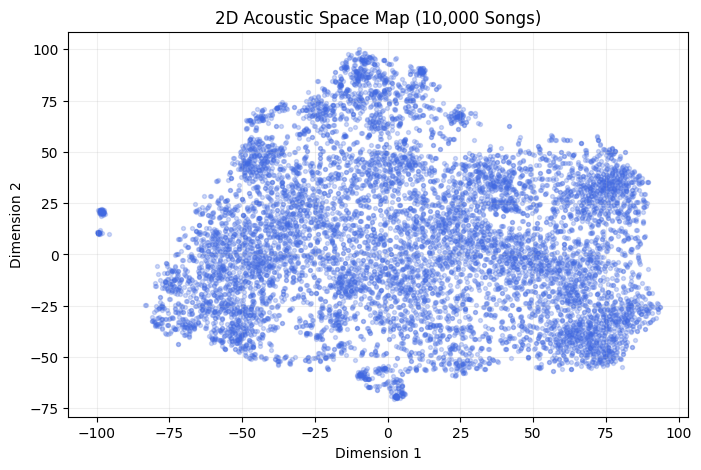

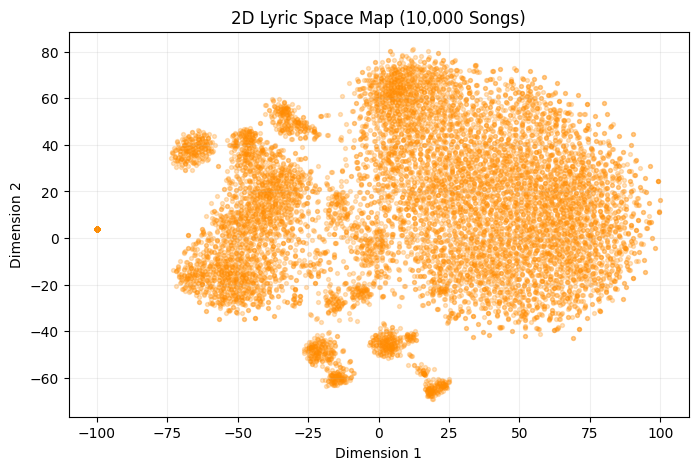

In [6]:
# Load 2D coordinates
umap_audio = pd.read_parquet(DATA_DIR / 'similarity' / 'umap_2d_audio.parquet')
umap_lyric = pd.read_parquet(DATA_DIR / 'similarity' / 'umap_2d_lyric.parquet')

# Plot Audio 2D space
plt.figure(figsize=(8, 5))
plt.scatter(umap_audio['proj_x'], umap_audio['proj_y'], alpha=0.25, s=8, c='royalblue')
plt.title("2D Acoustic Space Map (10,000 Songs)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, alpha=0.2)
plt.show()

# Plot Lyric 2D space
plt.figure(figsize=(8, 5))
plt.scatter(umap_lyric['proj_x'], umap_lyric['proj_y'], alpha=0.25, s=8, c='darkorange')
plt.title("2D Lyric Space Map (10,000 Songs)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True, alpha=0.2)
plt.show()


## 7. Machine Learning Splits (`splits/`)
- `artist_grouped_5fold.parquet`: GroupKFold by `artist_id` guaranteeing zero artist leakage across train and test folds.
- `temporal_split.parquet`: Chronological train / val / test evaluation.


In [7]:
splits = pd.read_parquet(DATA_DIR / 'splits' / 'artist_grouped_5fold.parquet')
temp_split = pd.read_parquet(DATA_DIR / 'splits' / 'temporal_split.parquet')

print("GroupKFold Distribution across 5 folds:")
print(splits['fold'].value_counts().sort_index())

print("\nTemporal Split Distribution:")
print(temp_split['split'].value_counts())


GroupKFold Distribution across 5 folds:
fold
0    2000
1    2000
2    2000
3    2000
4    2000
Name: count, dtype: int64

Temporal Split Distribution:
split
train    6549
test     2608
val       843
Name: count, dtype: int64
